# DSP Signal Visualization

Loads the newest `debug_<TIMESTAMP>.csv` from the `data/` dir and plots the raw and filtered acceleration magnitudes from the digital signal processing thread when running `tools/debug_stream.py`. 

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "data"
OPTIONAL_DATA_FILEPATH = None

## 1. Load data

In [2]:
candidates = sorted(DATA_DIR.glob("debug_*.csv"), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError(f"no debug_*.csv under {DATA_DIR}")

csv_path = OPTIONAL_DATA_FILEPATH if OPTIONAL_DATA_FILEPATH else candidates[-1]
print(f"Using: {csv_path.name}")

df = pd.read_csv(csv_path)
df = df.sort_values(by="timestampUs")

# Remove the 0 timestamp row
df = df.iloc[1:]

# Time axis: seconds from first sample (microsecond timestamps from firmware)
t = (df["timestampUs"] - df["timestampUs"].iloc[0]) * 1e-6

df.head()

Using: debug_20260430_153205.csv


,timestampUs,ax,ay,az,mag,slope
1,189699560,0.001987,-0.000065,0.000030,0.002662,-0.000212
2,189709540,0.002282,0.000647,-0.001036,0.002645,-0.000018
3,189718542,0.000318,-0.000319,0.000415,0.002159,-0.000486
4,189728552,-0.001467,-0.001493,-0.001254,0.002226,0.000067
5,189738532,-0.000357,-0.000382,0.002926,0.002405,0.000179


## 2. Time series: accelerations (ax, ay, az)

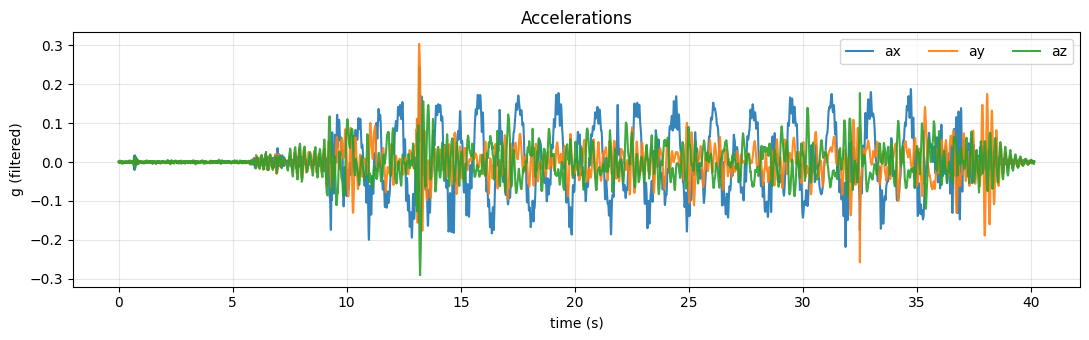

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, df["ax"], label="ax", alpha=0.9)
ax.plot(t, df["ay"], label="ay", alpha=0.9)
ax.plot(t, df["az"], label="az", alpha=0.9)
ax.set_xlabel("time (s)")
ax.set_ylabel("g (filtered)")
ax.set_title("Accelerations")
ax.legend(loc="upper right", ncol=3)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Magnitude and slope

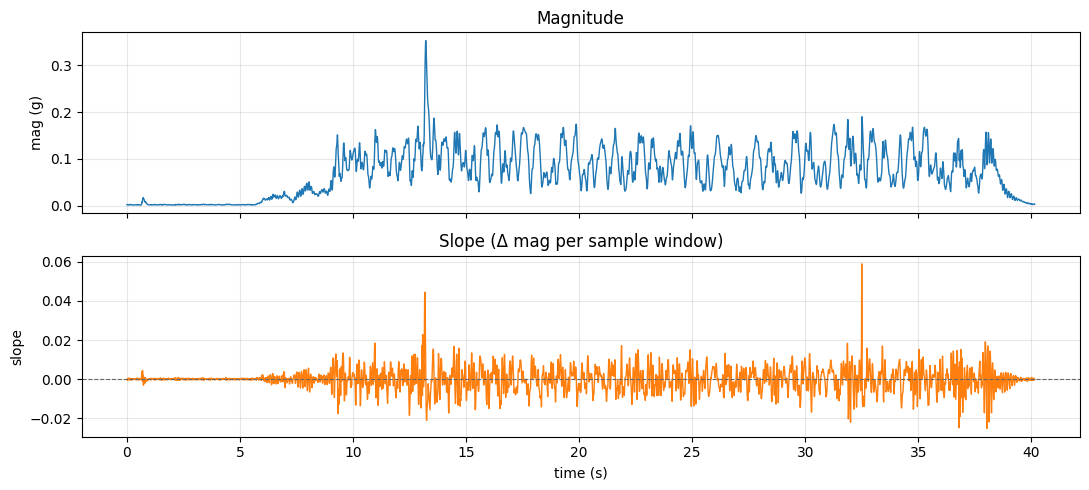

In [4]:
fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a0.plot(t, df["mag"], color="C0", lw=1.0)
a0.set_ylabel("mag (g)")
a0.set_title("Magnitude")
a0.grid(True, alpha=0.3)

a1.plot(t, df["slope"], color="C1", lw=1.0)
a1.set_xlabel("time (s)")
a1.set_ylabel("slope")
a1.set_title("Slope (Δ mag per sample window)")
a1.axhline(0, color="0.4", ls="--", lw=0.8)
a1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Step Detection

**Streaming** detector on scaled **mag**: same EMA detrend as before, plus a **4-state walking FSM** so steps are only counted inside a confirmed walk segment.

1. **EMA baseline** unchanged: `x_d = x - baseline`, `EMA_ALPHA = 0.02`, optional `MAG_SCALE` for CSV amplitude.
2. **States** (`state_seq`): `0` IDLE, `1` ARMING, `2` WALKING, `3` COOLDOWN.
3. **IDLE → ARMING**: `|x_d| > enter_th` **or** a qualifying local peak, sustained `ARM_CONFIRM_N` samples.
4. **ARMING → WALKING**: two valid step intervals in a row (`CADENCE_MIN` ≤ dt ≤ `CADENCE_MAX`); a long interval resets to IDLE. Sub-cadence peaks are skipped as duplicates.
5. **WALKING**: accept a step only if local max at `i-1`, `x_d[i-1] > PEAK_THRESHOLD`, cadence vs `last_step_t` is valid, `t_peak ≥ WARMUP_TIME`, and not in COOLDOWN. Long dt re-anchors phase (no step) to recover after missed peaks. Walk ends when `t - last_peak_t > NO_STEP_TIMEOUT` and `|x_d| < exit_th`.
6. **COOLDOWN**: after walk end, ignore peaks for `COOLDOWN_TIME`, then require `|x_d| < exit_th` for `LOW_ENERGY_SUSTAIN` before IDLE.

Optional counters in code: `n_reject_cadence`, `n_cooldown_suppressed` (comment the assignments to silence). Tune `CADENCE_MAX` / `NO_STEP_TIMEOUT` toward product values (~1.2 s) on calibrated firmware; notebook constants match the bundled CSV.


In [51]:
# --- Tunables (mirror in firmware headers) ---
EMA_ALPHA = 0.02

# Linear scale on mag before EMA (1.0 on MCU). Debug CSV exports here use smaller
# amplitude; ~4.35 aligns excursions with the thresholds below on bundled `debug_*.csv`.
MAG_SCALE = 4.35

enter_th = 0.15  # start motion
exit_th = 0.08  # stop motion

PEAK_THRESHOLD = 0.2

# --- Walking FSM ---
STATE_IDLE = 0
STATE_ARMING = 1
STATE_WALKING = 2
STATE_COOLDOWN = 3

ARM_CONFIRM_N = 3
NO_STEP_TIMEOUT = 2.0
COOLDOWN_TIME = 0.8
LOW_ENERGY_SUSTAIN = 0.8
WARMUP_TIME = 2.0

CADENCE_ALPHA = 0.2
CADENCE_FLOOR = 0.25
# Spec CADENCE_CEIL = 1.6; notebook CSV needs slight headroom on long dt.
CADENCE_CEIL = 1.74
# 0.4 per spec; 0.38 on this CSV reduces duplicate accepts between arm-swing peaks.
CADENCE_LOW_MULT = 0.38

COOLDOWN_Z_GATE = 0.18
PROMINENCE = 0.03
# Spec: 1.5 s quiet after last_step_t; lengthen if debug mag omits peaks for >1.5 s.
REST_PURGE_S = 2.5


def detect_steps_streaming(df):
    """
    EMA detrend + 4-state walking FSM; adaptive cadence in WALKING.

    Returns
    -------
    step_indices : list[int]
    step_times : list[float]
    x_detrended, baseline_arr : np.ndarray
    state_seq : np.ndarray int8  # 0 idle, 1 arming, 2 walking, 3 cooldown
    """
    mag = df["mag"].to_numpy(dtype=np.float64, copy=False)
    ts = df["timestampUs"].to_numpy(dtype=np.float64, copy=False)
    t = (ts - ts[0]) * 1e-6
    n = len(mag)

    if n == 0:
        e = np.array([], dtype=np.float64)
        return [], [], e, e, np.array([], dtype=np.int8)

    x_detrended = np.zeros(n, dtype=np.float64)
    baseline_arr = np.zeros(n, dtype=np.float64)
    state_seq = np.zeros(n, dtype=np.int8)

    step_indices = []
    step_times = []

    n_reject_cadence = 0
    n_cooldown_suppressed = 0

    baseline = float(mag[0]) * MAG_SCALE
    a = EMA_ALPHA

    state = STATE_IDLE
    arm_confirm = 0
    arming_times = []
    arming_indices = []
    last_step_t = -1.0e30
    last_peak_t = -1.0e30
    cadence_ema = None

    cooldown_enter_t = 0.0
    lockout_end_t = 0.0
    low_energy_start = -1.0

    for i in range(n):
        x = float(mag[i]) * MAG_SCALE
        baseline = a * x + (1.0 - a) * baseline
        x_d = x - baseline

        x_detrended[i] = x_d
        baseline_arr[i] = baseline

        ti = float(t[i])

        peak_candidate = False
        peak_idx = -1
        t_peak = 0.0
        if i >= 2:
            xd_im1 = x_detrended[i - 1]
            xd_i2 = x_detrended[i - 2]
            xd_i = x_d
            local_max = xd_im1 > xd_i2 and xd_im1 > xd_i
            dedge = xd_im1 - min(xd_i2, xd_i)
            prominent = dedge > PROMINENCE or (
                local_max and dedge > 0.0 and dedge <= PROMINENCE
            )
            peak_candidate = local_max and prominent and xd_im1 > PEAK_THRESHOLD
            if peak_candidate:
                peak_idx = i - 1
                t_peak = float(t[i - 1])

        if state == STATE_COOLDOWN:
            if ti < lockout_end_t:
                if peak_candidate and abs(x_d) > COOLDOWN_Z_GATE:
                    n_cooldown_suppressed += 1
            else:
                if abs(x_d) < exit_th:
                    if low_energy_start < 0.0:
                        low_energy_start = ti
                    elif ti - low_energy_start >= LOW_ENERGY_SUSTAIN:
                        state = STATE_IDLE
                        arm_confirm = 0
                        arming_times.clear()
                        arming_indices.clear()
                        low_energy_start = -1.0
                else:
                    low_energy_start = -1.0
                if peak_candidate and abs(x_d) > COOLDOWN_Z_GATE:
                    n_cooldown_suppressed += 1
            state_seq[i] = state
            continue

        if state == STATE_WALKING:
            if peak_candidate and t_peak >= WARMUP_TIME:
                last_peak_t = t_peak
                dt = t_peak - last_step_t
                if cadence_ema is None:
                    low_b = CADENCE_FLOOR
                    high_b = CADENCE_CEIL
                else:
                    low_b = max(CADENCE_LOW_MULT * cadence_ema, CADENCE_FLOOR)
                    high_b = min(1.8 * cadence_ema, CADENCE_CEIL)
                if dt < low_b:
                    n_reject_cadence += 1
                elif dt > high_b:
                    n_reject_cadence += 1
                    last_step_t = t_peak
                else:
                    step_indices.append(peak_idx)
                    step_times.append(t_peak)
                    last_step_t = t_peak
                    if cadence_ema is None:
                        cadence_ema = min(max(dt, CADENCE_FLOOR), CADENCE_CEIL)
                    else:
                        cadence_ema = (
                            CADENCE_ALPHA * dt
                            + (1.0 - CADENCE_ALPHA) * cadence_ema
                        )
                        cadence_ema = min(
                            max(cadence_ema, CADENCE_FLOOR), CADENCE_CEIL
                        )

            if abs(x_d) < exit_th and (ti - last_step_t) > REST_PURGE_S:
                state = STATE_COOLDOWN
                cadence_ema = None
                cooldown_enter_t = ti
                lockout_end_t = ti + COOLDOWN_TIME
                low_energy_start = -1.0
                state_seq[i] = state
                continue

            if ti - last_peak_t > NO_STEP_TIMEOUT and abs(x_d) < exit_th:
                state = STATE_COOLDOWN
                cadence_ema = None
                cooldown_enter_t = ti
                lockout_end_t = ti + COOLDOWN_TIME
                low_energy_start = -1.0
                state_seq[i] = state
                continue
            state_seq[i] = state
            continue

        if state == STATE_IDLE:
            trig = (abs(x_d) > enter_th) or peak_candidate
            if trig:
                arm_confirm += 1
            else:
                arm_confirm = 0
            if arm_confirm >= ARM_CONFIRM_N:
                state = STATE_ARMING
                arm_confirm = 0
                arming_times.clear()
                arming_indices.clear()

        if state == STATE_ARMING:
            if peak_candidate and t_peak >= WARMUP_TIME:
                if len(arming_times) == 0:
                    arming_times.append(t_peak)
                    arming_indices.append(peak_idx)
                else:
                    dt = t_peak - arming_times[-1]
                    if dt < CADENCE_FLOOR:
                        pass
                    elif dt > CADENCE_CEIL:
                        state = STATE_IDLE
                        arm_confirm = 0
                        arming_times.clear()
                        arming_indices.clear()
                    else:
                        arming_times.append(t_peak)
                        arming_indices.append(peak_idx)
                        if len(arming_times) >= 2:
                            arming_dt1 = arming_times[-1] - arming_times[-2]
                            consistent = arming_dt1 < 1.8 * CADENCE_CEIL
                            if consistent:
                                state = STATE_WALKING
                                step_indices.extend(arming_indices)
                                step_times.extend(arming_times)
                                last_step_t = arming_times[-1]
                                last_peak_t = last_step_t
                                cadence_ema = None
                                arming_times.clear()
                                arming_indices.clear()
                            else:
                                arming_times[:] = [arming_times[-1]]
                                arming_indices[:] = [arming_indices[-1]]

        state_seq[i] = state

    return step_indices, step_times, x_detrended, baseline_arr, state_seq


In [52]:
out = detect_steps_streaming(df)
(
    step_indices,
    step_times,
    x_detrended,
    baseline_arr,
    state_seq,
) = out

print(f"Detected steps: {len(step_indices)}")


Detected steps: 28


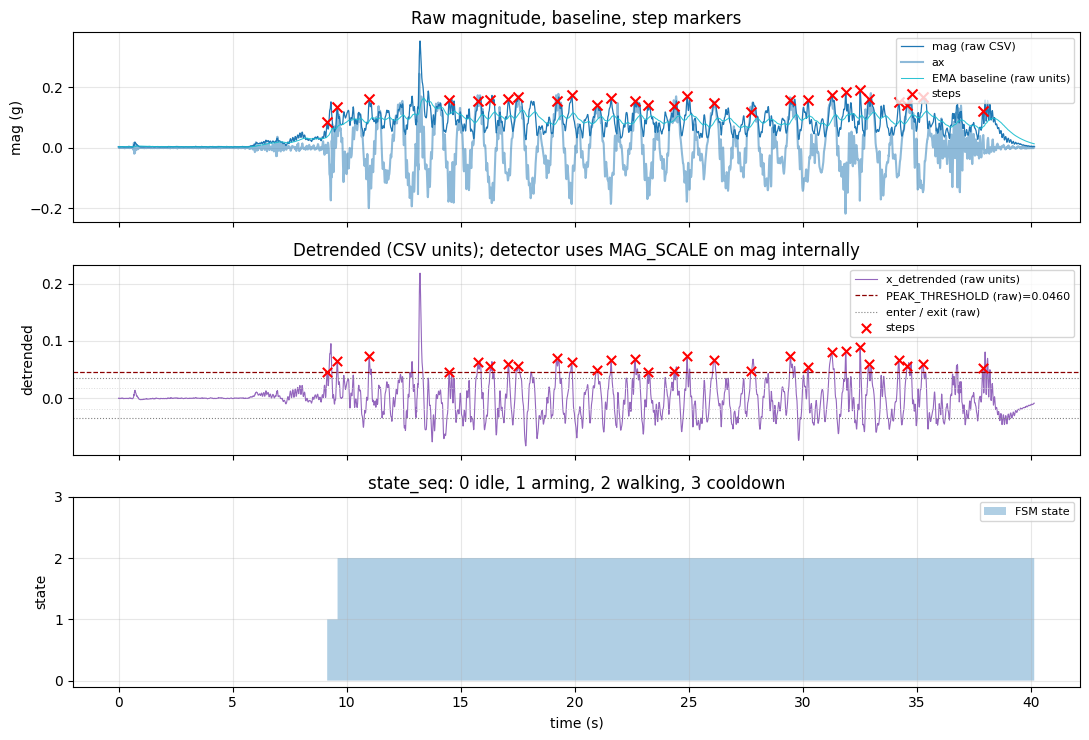

In [53]:
t_np = np.asarray(t, dtype=float)
mag_np = np.asarray(df["mag"], dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)

ax0 = axes[0]
ax0.plot(t_np, mag_np, label="mag (raw CSV)", color="tab:blue", lw=0.9)
ax0.plot(t_np, df["ax"], label="ax", alpha=0.5)
ax0.plot(
    t_np,
    baseline_arr / MAG_SCALE,
    label="EMA baseline (raw units)",
    color="tab:cyan",
    lw=0.75,
    alpha=0.9,
)
if len(step_indices):
    ax0.scatter(
        t_np[step_indices],
        mag_np[step_indices],
        color="red",
        s=52,
        marker="x",
        zorder=5,
        label="steps",
    )
ax0.set_ylabel("mag (g)")
ax0.set_title("Raw magnitude, baseline, step markers")
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper right", fontsize=8)

ax1 = axes[1]
xd_plot = x_detrended / MAG_SCALE
ax1.plot(t_np, xd_plot, color="tab:purple", lw=0.8, label="x_detrended (raw units)")
ax1.axhline(
    PEAK_THRESHOLD / MAG_SCALE,
    color="darkred",
    ls="--",
    lw=0.9,
    label=f"PEAK_THRESHOLD (raw)={PEAK_THRESHOLD/MAG_SCALE:.4f}",
)
ax1.axhline(enter_th / MAG_SCALE, color="gray", ls=":", lw=0.8, label="enter / exit (raw)")
ax1.axhline(-enter_th / MAG_SCALE, color="gray", ls=":", lw=0.8)
ax1.axhline(exit_th / MAG_SCALE, color="lightgray", ls=":", lw=0.7, alpha=0.8)
ax1.axhline(-exit_th / MAG_SCALE, color="lightgray", ls=":", lw=0.7, alpha=0.8)
if len(step_indices):
    ax1.scatter(
        t_np[step_indices],
        xd_plot[step_indices],
        color="red",
        s=45,
        marker="x",
        zorder=5,
        label="steps",
    )
ax1.set_ylabel("detrended")
ax1.set_title("Detrended (CSV units); detector uses MAG_SCALE on mag internally")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right", fontsize=8)

ax2 = axes[2]
ax2.fill_between(t_np, 0.0, state_seq.astype(float), step="post", alpha=0.35, label="FSM state")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("state")
ax2.set_title("state_seq: 0 idle, 1 arming, 2 walking, 3 cooldown")
ax2.set_yticks([0, 1, 2, 3])
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()


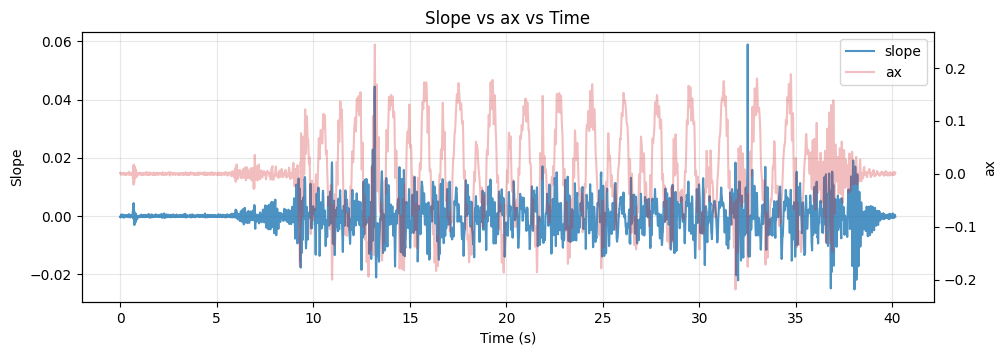

In [20]:
fig, ax1 = plt.subplots(figsize=(11, 3.5))

ax1.plot(t, df["slope"], label="slope", alpha=0.8, color="tab:blue")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Slope")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t, df["ax"], label="ax", alpha=0.3, color="tab:red")
ax2.set_ylabel("ax")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Slope vs ax vs Time")

plt.show()
